# 🌱 Plant Growth Monitor
## Use Case A — Sprout Detection: Full Demonstration

This notebook provides a guided walkthrough of the entire sprout detection pipeline.
It demonstrates every layer individually, then shows the cascade in action.

---

### Pipeline Architecture

```
Input Image (photo or video frame)
         │
         ▼
Layer 1 — Classical HSV Masking       Free · CPU · <10ms
         │  confidence ≥ 0.60  → return result
         │  confidence < 0.60  ↓
Layer 2 — CLIP Zero-Shot              Free · GPU recommended · 1–3s
         │  confidence ≥ 0.60  → return result
         │  confidence < 0.60  ↓
Layer 3 — Gemini Flash API            ~$0.001/call · any hardware · 1–2s
         └→ return result
```

---
## 1. Setup & Imports

In [1]:
import sys, os

# Add project root to path — adjust this if running from a different directory
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ── Project imports ─────────────────────────────────────────────────────────
from config import CONFIG
from sprout_detection.cascade import SproutCascade
from sprout_detection.detectors.hsv_detector import HSVDetector
from sprout_detection.detectors.clip_detector import CLIPDetector
from sprout_detection.detectors.gemini_detector import GeminiDetector
from sprout_detection.utils.image_gen import (
    make_sprout_image, make_bare_soil_image, make_ambiguous_image, make_batch
)
from sprout_detection.utils.visualiser import (
    visualise_hsv, visualise_clip, visualise_gemini,
    visualise_result, visualise_cascade_summary
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print("✅ All imports successful.")
print(f"   Confidence threshold : {CONFIG['confidence_threshold']}")
print(f"   Gemini API key set   : {'Yes ✅' if CONFIG.get('gemini_api_key') else 'No ⏭️ (Layer 3 will be skipped)'}")

✅ All imports successful.
   Confidence threshold : 0.6
   Gemini API key set   : No ⏭️ (Layer 3 will be skipped)


---
## 2. Generate Test Images

We generate three synthetic test images:
- **Sprout** — clear green plant on brown soil → should give confident detection
- **Bare soil** — no green at all → should give confident rejection
- **Ambiguous** — tiny green patch right at the detection boundary → should trigger cascade escalation

In [2]:
SPROUT_PATH    = ('image_1.jpg')
BARE_PATH      = ('image_2.jpg')

---
## 3. Layer 1 — HSV Masking

**How it works:**
1. Convert image from BGR to HSV colour space
2. Create a binary mask for pixels in the green HSV range (H: 35–85)
3. Apply morphological OPEN + CLOSE to remove noise
4. If green pixel fraction ≥ threshold (0.01) → sprout detected
5. Confidence scales with how far the ratio is from the threshold boundary

> **Typical performance:** <10 ms per image. Zero cost. No model download.

In [3]:
# Create the Layer 1 detector
hsv_detector = HSVDetector(config=CONFIG)
print(f"HSVDetector: {hsv_detector}")
print(f"Green HSV range: H={CONFIG['hsv_lower'][0]}–{CONFIG['hsv_upper'][0]}, "
      f"S={CONFIG['hsv_lower'][1]}–{CONFIG['hsv_upper'][1]}, "
      f"V={CONFIG['hsv_lower'][2]}–{CONFIG['hsv_upper'][2]}")
print(f"Green ratio threshold: {CONFIG['hsv_green_ratio_threshold']:.3f} "
      f"({CONFIG['hsv_green_ratio_threshold']*100:.1f}% of pixels)")

HSVDetector: <HSVDetector layer='hsv_masking'>
Green HSV range: H=35–85, S=40–255, V=40–255
Green ratio threshold: 0.010 (1.0% of pixels)


Layer 1 Test 1: Sprout Image
🌱 SproutResult | detected=True | confidence=0.87 | method=hsv_masking
  Green ratio : 0.0515  (threshold = 0.01)
  Reasoning   : Green pixel ratio = 0.0515 (above threshold 0.01). Sprout detected.


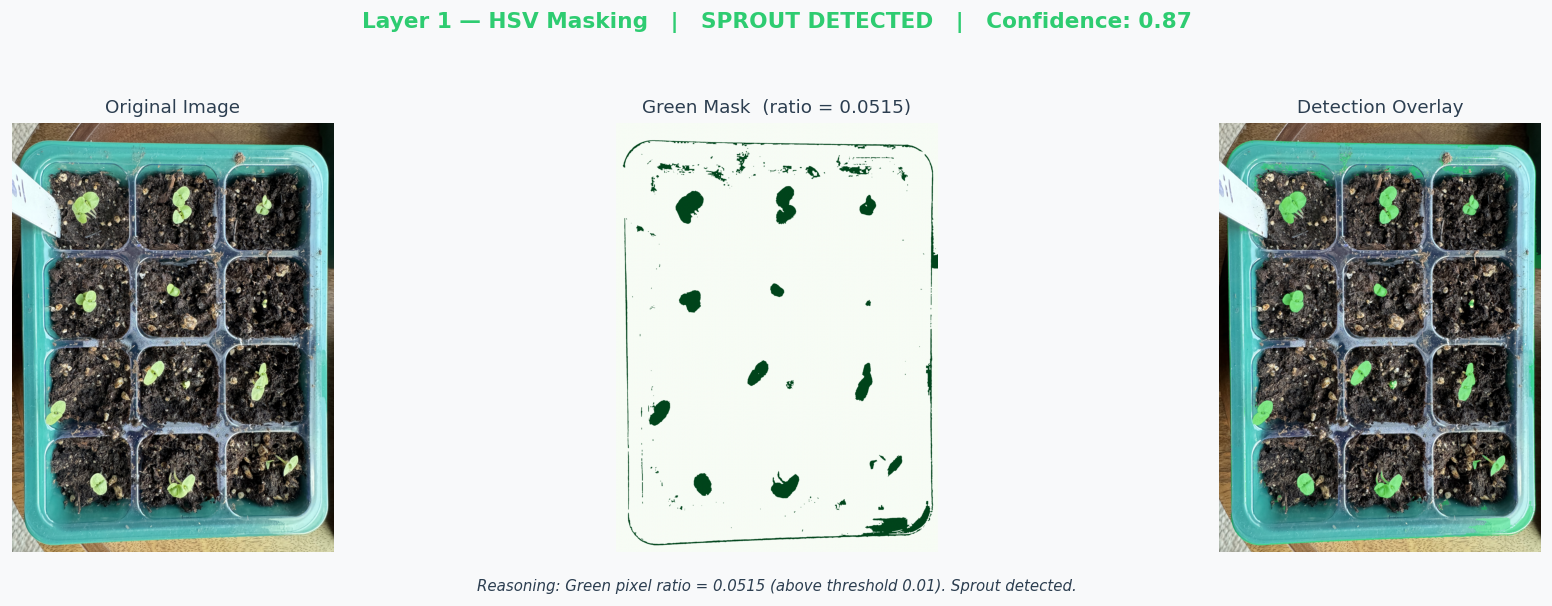

In [4]:
# ── Test 1: Clear sprout image ───────────────────────────────────────────────
print("=" * 55)
print("Layer 1 Test 1: Sprout Image")
print("=" * 55)

result_sprout = hsv_detector.detect(SPROUT_PATH)
print(result_sprout)
print(f"  Green ratio : {result_sprout.green_ratio:.4f}  "
      f"(threshold = {CONFIG['hsv_green_ratio_threshold']})")
print(f"  Reasoning   : {result_sprout.reasoning}")

# Visualise
visualise_hsv(SPROUT_PATH, result_sprout)

Layer 1 Test 2: Bare Soil Image
🌱 SproutResult | detected=True | confidence=0.95 | method=hsv_masking
  Green ratio : 0.1504
  Reasoning   : Green pixel ratio = 0.1504 (above threshold 0.01). Sprout detected.


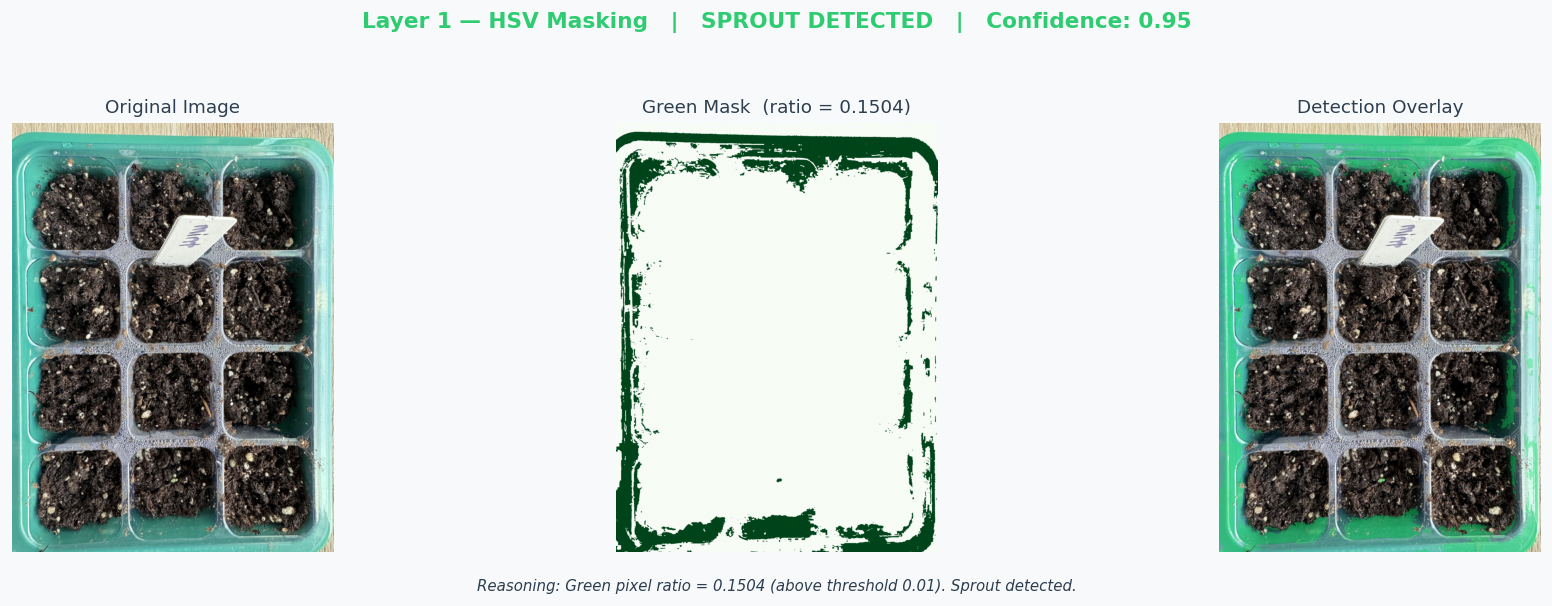

In [5]:
# ── Test 2: Bare soil ────────────────────────────────────────────────────────
print("=" * 55)
print("Layer 1 Test 2: Bare Soil Image")
print("=" * 55)

result_bare = hsv_detector.detect(BARE_PATH)
print(result_bare)
print(f"  Green ratio : {result_bare.green_ratio:.4f}")
print(f"  Reasoning   : {result_bare.reasoning}")

visualise_hsv(BARE_PATH, result_bare)

---
## 4. Layer 2 — CLIP Zero-Shot Classification

**How it works:**
1. Load CLIP ViT-B/32 (downloads ~350 MB on first use, then cached)
2. Encode the image and all text prompts into a shared embedding space
3. Compute cosine similarity → softmax probabilities across all prompts
4. Sum probability mass over "sprout" prompts vs "no sprout" prompts
5. The larger mass determines the prediction

> **Typical performance:** 1–3 s on CPU, ~100 ms on GPU. No threshold tuning needed.

In [6]:
# Create the Layer 2 detector
# NOTE: First call below will download CLIP ViT-B/32 (~350 MB)
clip_detector = CLIPDetector(config=CONFIG)
print(f"CLIPDetector: {clip_detector}")
print(f"Model loaded : {clip_detector.is_loaded()}")
print(f"\nText prompts configured:")
for i, p in enumerate(CONFIG['clip_prompts']):
    tag = "[SPROUT]" if i in CONFIG['clip_sprout_prompt_indices'] else "[NO SPROUT]"
    print(f"  [{i}] {tag:<12} {p}")

CLIPDetector: <CLIPDetector layer='clip_zero_shot'>
Model loaded : False

Text prompts configured:
  [0] [SPROUT]     green sprout emerging from soil
  [1] [SPROUT]     seed tray with plants
  [2] [NO SPROUT]  bare soil with no plant
  [3] [NO SPROUT]  empty seed tray


In [7]:
# ── CLIP on all three test images ────────────────────────────────────────────
for path, label in [
    (SPROUT_PATH, "Sprout"),
    (BARE_PATH, "Bare Soil")
]:
    print(f"\n{'─'*50}")
    print(f"CLIP Test: {label}")
    print(f"{'─'*50}")
    result = clip_detector.detect(path, escalated=False)
    print(result)
    print(f"  Reasoning : {result.reasoning}")
    if result.clip_scores:
        for prompt, score in result.clip_scores.items():
            marker = "◀" if score == max(result.clip_scores.values()) else " "
            bar = "█" * int(score * 40)
            print(f"  {score:.3f} {bar:<40} {marker}  {prompt}")


──────────────────────────────────────────────────
CLIP Test: Sprout
──────────────────────────────────────────────────
[CLIPDetector] Loading 'ViT-B/32' on cpu. First load downloads ~350 MB — subsequent loads are instant.
[CLIPDetector] Model loaded successfully.
🌱 SproutResult | detected=True | confidence=0.61 | method=clip_zero_shot
  Reasoning : Best matching prompt: 'green sprout emerging from soil' (score=0.396). Sprout mass=0.613, No-sprout mass=0.387.
  0.396 ███████████████                          ◀  green sprout emerging from soil
  0.217 ████████                                    seed tray with plants
  0.023                                             bare soil with no plant
  0.364 ██████████████                              empty seed tray

──────────────────────────────────────────────────
CLIP Test: Bare Soil
──────────────────────────────────────────────────
🌱 SproutResult | detected=True | confidence=0.51 | method=clip_zero_shot
  Reasoning : Best matching prompt: 

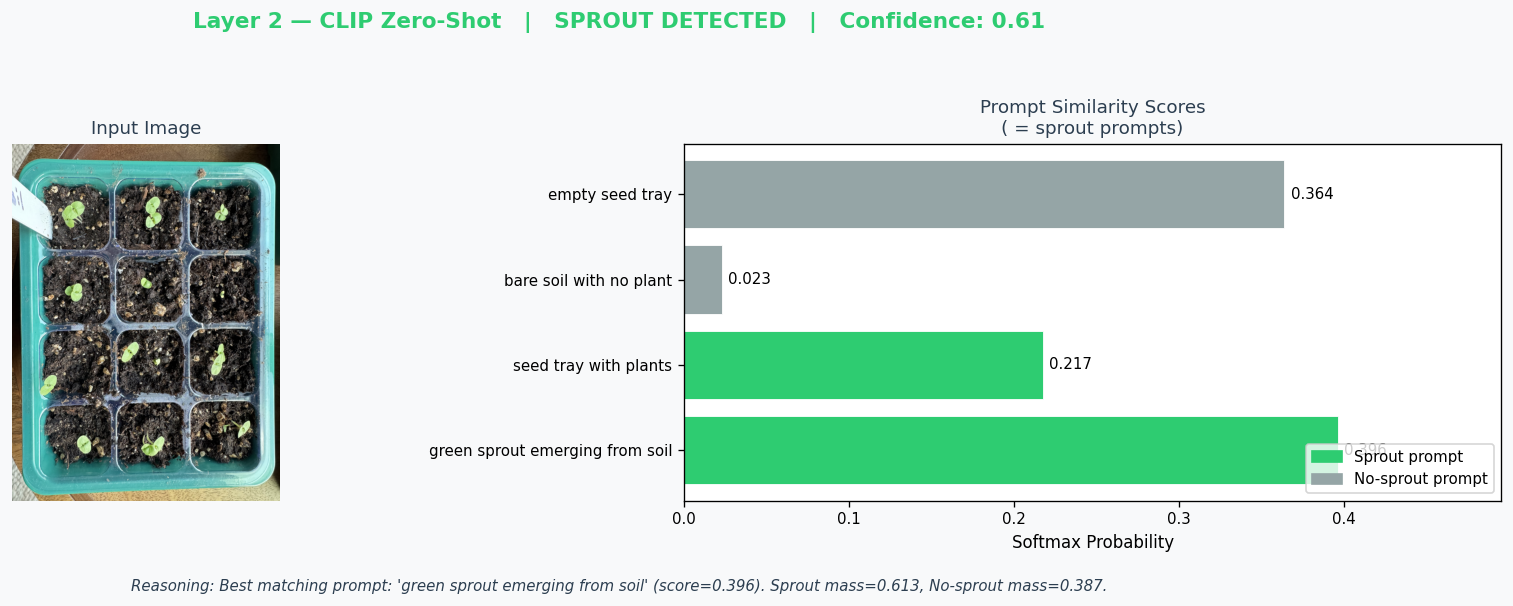

In [8]:
# ── Visualise CLIP result for sprout image ───────────────────────────────────
result_clip_sprout = clip_detector.detect(SPROUT_PATH)
visualise_clip(SPROUT_PATH, result_clip_sprout)

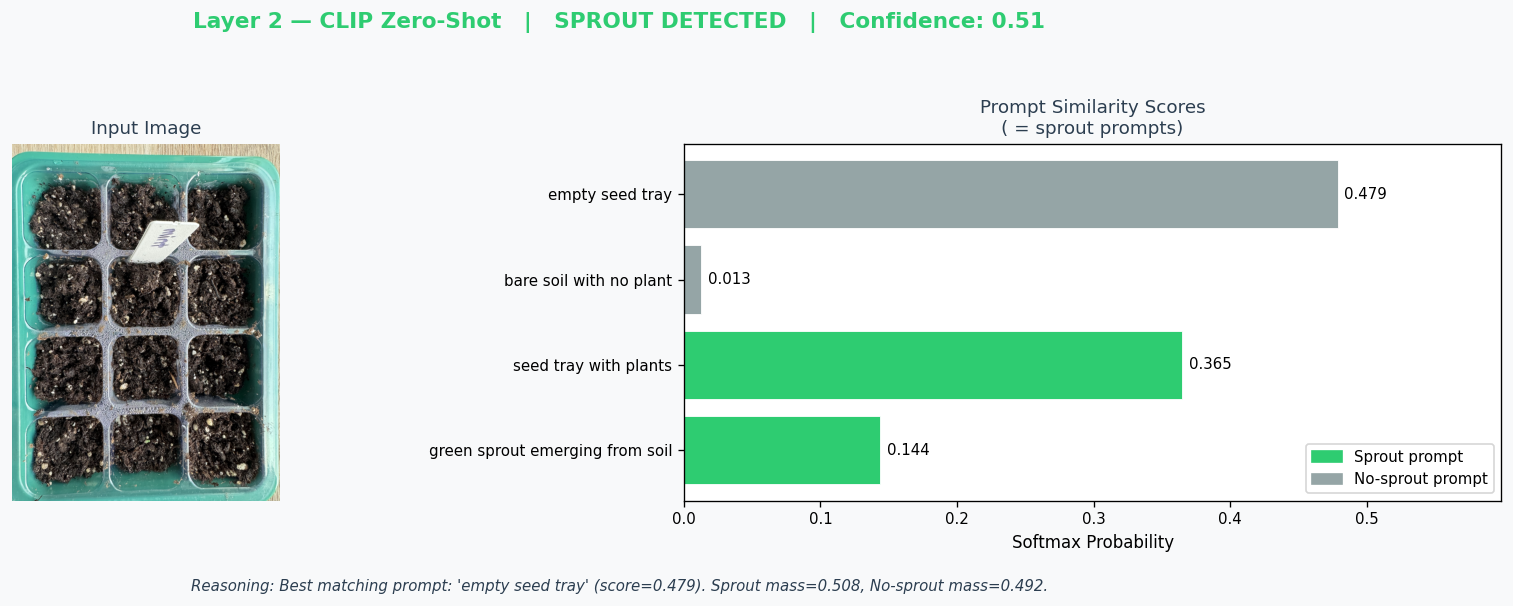

In [9]:
# ── Visualise CLIP result for bare soil ─────────────────────────────────────
result_clip_bare = clip_detector.detect(BARE_PATH)
visualise_clip(BARE_PATH, result_clip_bare)

---
## 6. Full Cascade Demo

Run the complete three-layer cascade on all test images.
Watch how the cascade resolves at the earliest possible layer.

In [10]:
# Create the cascade with verbose output to see escalation in action
cascade = SproutCascade(
    config=CONFIG,
    verbose=True  # Show every step
)

print("Cascade created.")
print(f"  Layer 1: {cascade._layer1}")
print(f"  Layer 2: {cascade._layer2}")
print(f"  Layer 3: {cascade._layer3}")

Cascade created.
  Layer 1: <HSVDetector layer='hsv_masking'>
  Layer 2: <CLIPDetector layer='clip_zero_shot'>
  Layer 3: <GeminiDetector layer='gemini_flash_api'>



═══════════════════════════════════════════════════════
CASCADE TEST 1: Clear Sprout Image
═══════════════════════════════════════════════════════

🔍 Analysing: image_1.jpg
   Cascade threshold: 0.6
   Layer 1 → HSV Masking...
             confidence=0.873  green_ratio=0.0515
   ✅ Resolved at Layer 1 (confidence=0.873)


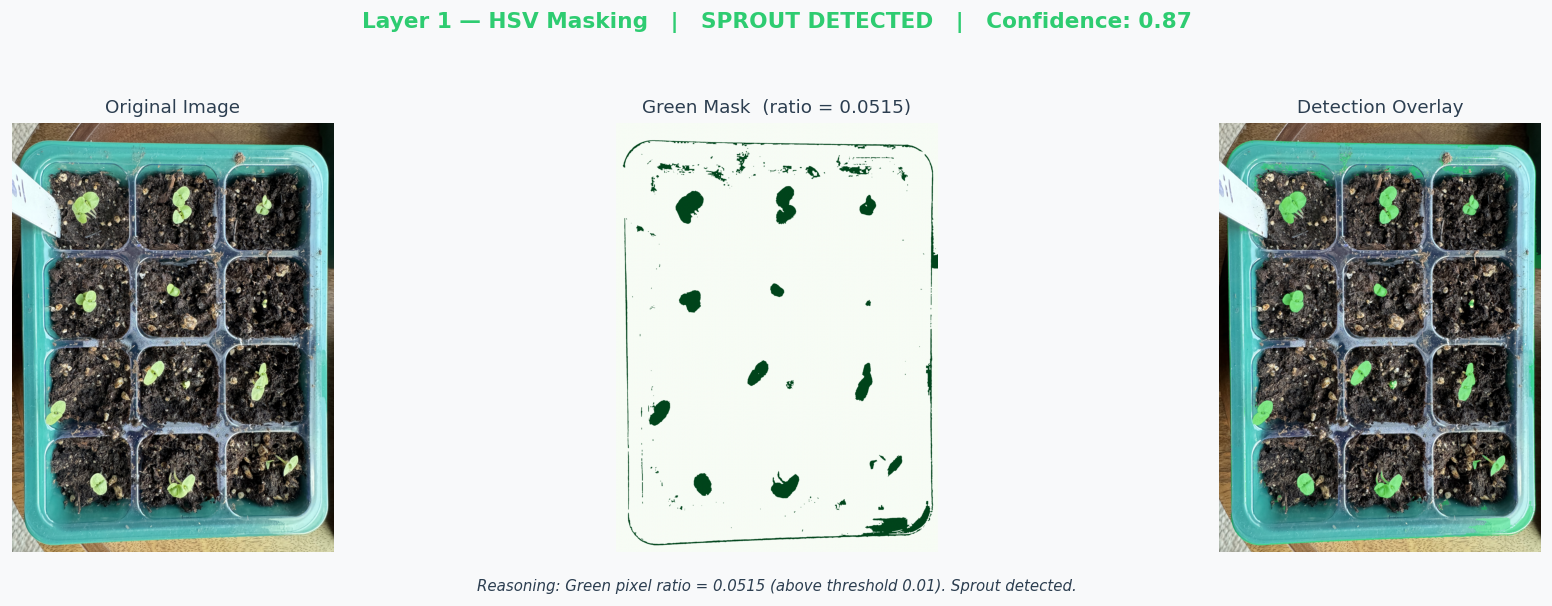

In [11]:
# ── Test 1: Clear sprout (should resolve at Layer 1) ─────────────────────────
print("\n" + "═" * 55)
print("CASCADE TEST 1: Clear Sprout Image")
print("═" * 55)
r1 = cascade.analyze(SPROUT_PATH)
visualise_result(SPROUT_PATH, r1)

In [12]:
# ── Test 2: Bare soil (should resolve at Layer 1) ────────────────────────────
print("\n" + "═" * 55)
print("CASCADE TEST 2: Bare Soil")
print("═" * 55)
r2 = cascade.analyze(BARE_PATH)
#visualise_result(BARE_PATH, r2)


═══════════════════════════════════════════════════════
CASCADE TEST 2: Bare Soil
═══════════════════════════════════════════════════════

🔍 Analysing: image_2.jpg
   Cascade threshold: 0.6
   Layer 1 → HSV Masking...
             confidence=0.950  green_ratio=0.1504
   ✅ Resolved at Layer 1 (confidence=0.950)


---
## 7. Cascade Escalation Demo

This section uses a **very high threshold (0.95)** to force the cascade to escalate
through all layers, illustrating exactly what happens at each escalation step.

In [13]:
# Build a high-threshold config to force escalation
escalation_config = dict(CONFIG)
escalation_config["confidence_threshold"] = 0.95  # Very high → forces escalation
escalation_config["gemini_api_key"] = CONFIG.get("gemini_api_key", "")  # Keep existing key

esc_cascade = SproutCascade(
    config=escalation_config,
    log_path="logs/escalation_demo.jsonl",
    verbose=True,
)

print("🔬 Escalation Demo — threshold set to 0.95 to force all layers to run")
print()
result_esc = esc_cascade.analyze(SPROUT_PATH)
print(f"\nFinal result method : {result_esc.method}")
print(f"Escalated           : {result_esc.escalated}")

🔬 Escalation Demo — threshold set to 0.95 to force all layers to run


🔍 Analysing: image_1.jpg
   Cascade threshold: 0.95
   Layer 1 → HSV Masking...
             confidence=0.873  green_ratio=0.0515
   ⚠️  Layer 1 confidence 0.873 < 0.95 → escalating to Layer 2 (CLIP)
[CLIPDetector] Loading 'ViT-B/32' on cpu. First load downloads ~350 MB — subsequent loads are instant.
[CLIPDetector] Model loaded successfully.
   Layer 2 → CLIP  confidence=0.613
   ⚠️  Layer 2 confidence 0.613 < 0.95 → Layer 3 unavailable (GEMINI_API_KEY not set). Returning Layer 2 result.

Final result method : clip_zero_shot
Escalated           : True
